In [1]:
# !pip install gaston-spatial
# !pip install scanpy
# !pip install glmpca
# !pip install kneed
# !pip install squidpy
# !pip install "zarr==2.18.7" --no-cache-dir
# !pip install openpyxl

In [2]:
import sys
import os
from collections import defaultdict
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
from glmpca import glmpca
from itertools import combinations
import torch

import sys
from importlib import reload

import gaston
from gaston import neural_net,cluster_plotting, dp_related, segmented_fit, restrict_spots, model_selection
from gaston import binning_and_plotting, isodepth_scaling, run_slurm_scripts, parse_adata
from gaston import spatial_gene_classification, plot_cell_types, filter_genes, process_NN_output

import seaborn as sns
import math
import gzip
import shutil

/Users/jishar/Documents/points2regions/p2r_env/lib/python3.13/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/jishar/Documents/points2regions/p2r_env/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/jishar/Documents/points2regions/p2r_env/lib/python3.13/site-packages/squidpy/gr/_utils.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  CAN

In [3]:
# CHANGE TO: location of Xenium data folder
folder = 'data/Xenium_V1_FF_Mouse_Brain_Coronal_Subset_CTX_HP_outs/'

In [4]:
with gzip.open(f"{folder}cells.csv.gz", "rb") as f_in:
    with open(f"{folder}cells.csv", "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

print("Decompressed to cells.csv")

Decompressed to cells.csv


In [5]:
# ## SPECIFIC TO EXAMPLE DATA
# # Read Excel file
# df = pd.read_excel(f"{folder}Cell_Barcode_Type_Matrices.xlsx", sheet_name=0)

# df.rename(columns={"Annotation":"Cluster"}, inplace=True)

# df.to_csv(f"{folder}Cell_Barcode_Type_Matrices.csv", index=False)

# print("Converted cells.xlsx → cells.csv")

In [6]:
def get_gaston_input_xenium(folder,filter_zero_cells=False):
    adata = sc.read_10x_h5(filename=folder+'cell_feature_matrix.h5')

    df = pd.read_csv(folder+"cells.csv")
    df.set_index(adata.obs_names, inplace=True)
    adata.obs = df.copy()

    adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].copy().to_numpy()

    counts_mat=np.array(adata.X.todense())
    coords_mat=adata.obs[["x_centroid", "y_centroid"]].to_numpy()

    # cts=pd.read_csv(folder+'Cell_Barcode_Type_Matrices.csv')
    # cts=np.array(cts['Cluster'])

    gene_labels=np.array(adata.var.index)

    if filter_zero_cells:
        inds_to_keep=np.where(np.sum(counts_mat,1)>0)[0]
        counts_mat=counts_mat[inds_to_keep,:]
        coords_mat=coords_mat[inds_to_keep,:]
        cts=cts[inds_to_keep]

    return counts_mat, coords_mat, gene_labels, adata
    # cts

In [7]:
# counts_mat,coords_mat,gene_labels,cell_types = parse_adata.get_gaston_input_xenium(folder)

counts_mat,coords_mat,gene_labels,adata = get_gaston_input_xenium(folder)

In [8]:
# GLM-PCA parameters
num_dims=20
penalty=5

# CHANGE THESE PARAMETERS TO REDUCE RUNTIME
num_iters=30
eps=1e-4
num_genes=10000

counts_mat_glmpca=counts_mat[:,np.argsort(np.sum(counts_mat, axis=0))[-num_genes:]]
glmpca_res=glmpca.glmpca(counts_mat_glmpca.T, num_dims, fam="poi", penalty=penalty, verbose=True,
                        ctl = {"maxIter":num_iters, "eps":eps, "optimizeTheta":True})
A = glmpca_res['factors'] # should be of size N x num_dims, where each column is a PC

Iteration: 0 | deviance=1.9506E+7
Iteration: 1 | deviance=1.9506E+7
Iteration: 2 | deviance=1.4490E+7
Iteration: 3 | deviance=9.8035E+6
Iteration: 4 | deviance=8.2979E+6
Iteration: 5 | deviance=7.6967E+6
Iteration: 6 | deviance=7.3904E+6
Iteration: 7 | deviance=7.2109E+6
Iteration: 8 | deviance=7.0930E+6
Iteration: 9 | deviance=7.0093E+6
Iteration: 10 | deviance=6.9467E+6
Iteration: 11 | deviance=6.8979E+6
Iteration: 12 | deviance=6.8587E+6
Iteration: 13 | deviance=6.8262E+6
Iteration: 14 | deviance=6.7987E+6
Iteration: 15 | deviance=6.7750E+6
Iteration: 16 | deviance=6.7541E+6
Iteration: 17 | deviance=6.7355E+6
Iteration: 18 | deviance=6.7187E+6
Iteration: 19 | deviance=6.7034E+6
Iteration: 20 | deviance=6.6893E+6
Iteration: 21 | deviance=6.6762E+6
Iteration: 22 | deviance=6.6641E+6
Iteration: 23 | deviance=6.6528E+6
Iteration: 24 | deviance=6.6422E+6
Iteration: 25 | deviance=6.6322E+6
Iteration: 26 | deviance=6.6228E+6
Iteration: 27 | deviance=6.6139E+6
Iteration: 28 | deviance=6.605

In [9]:
np.save('results/glmpca.npy', A)

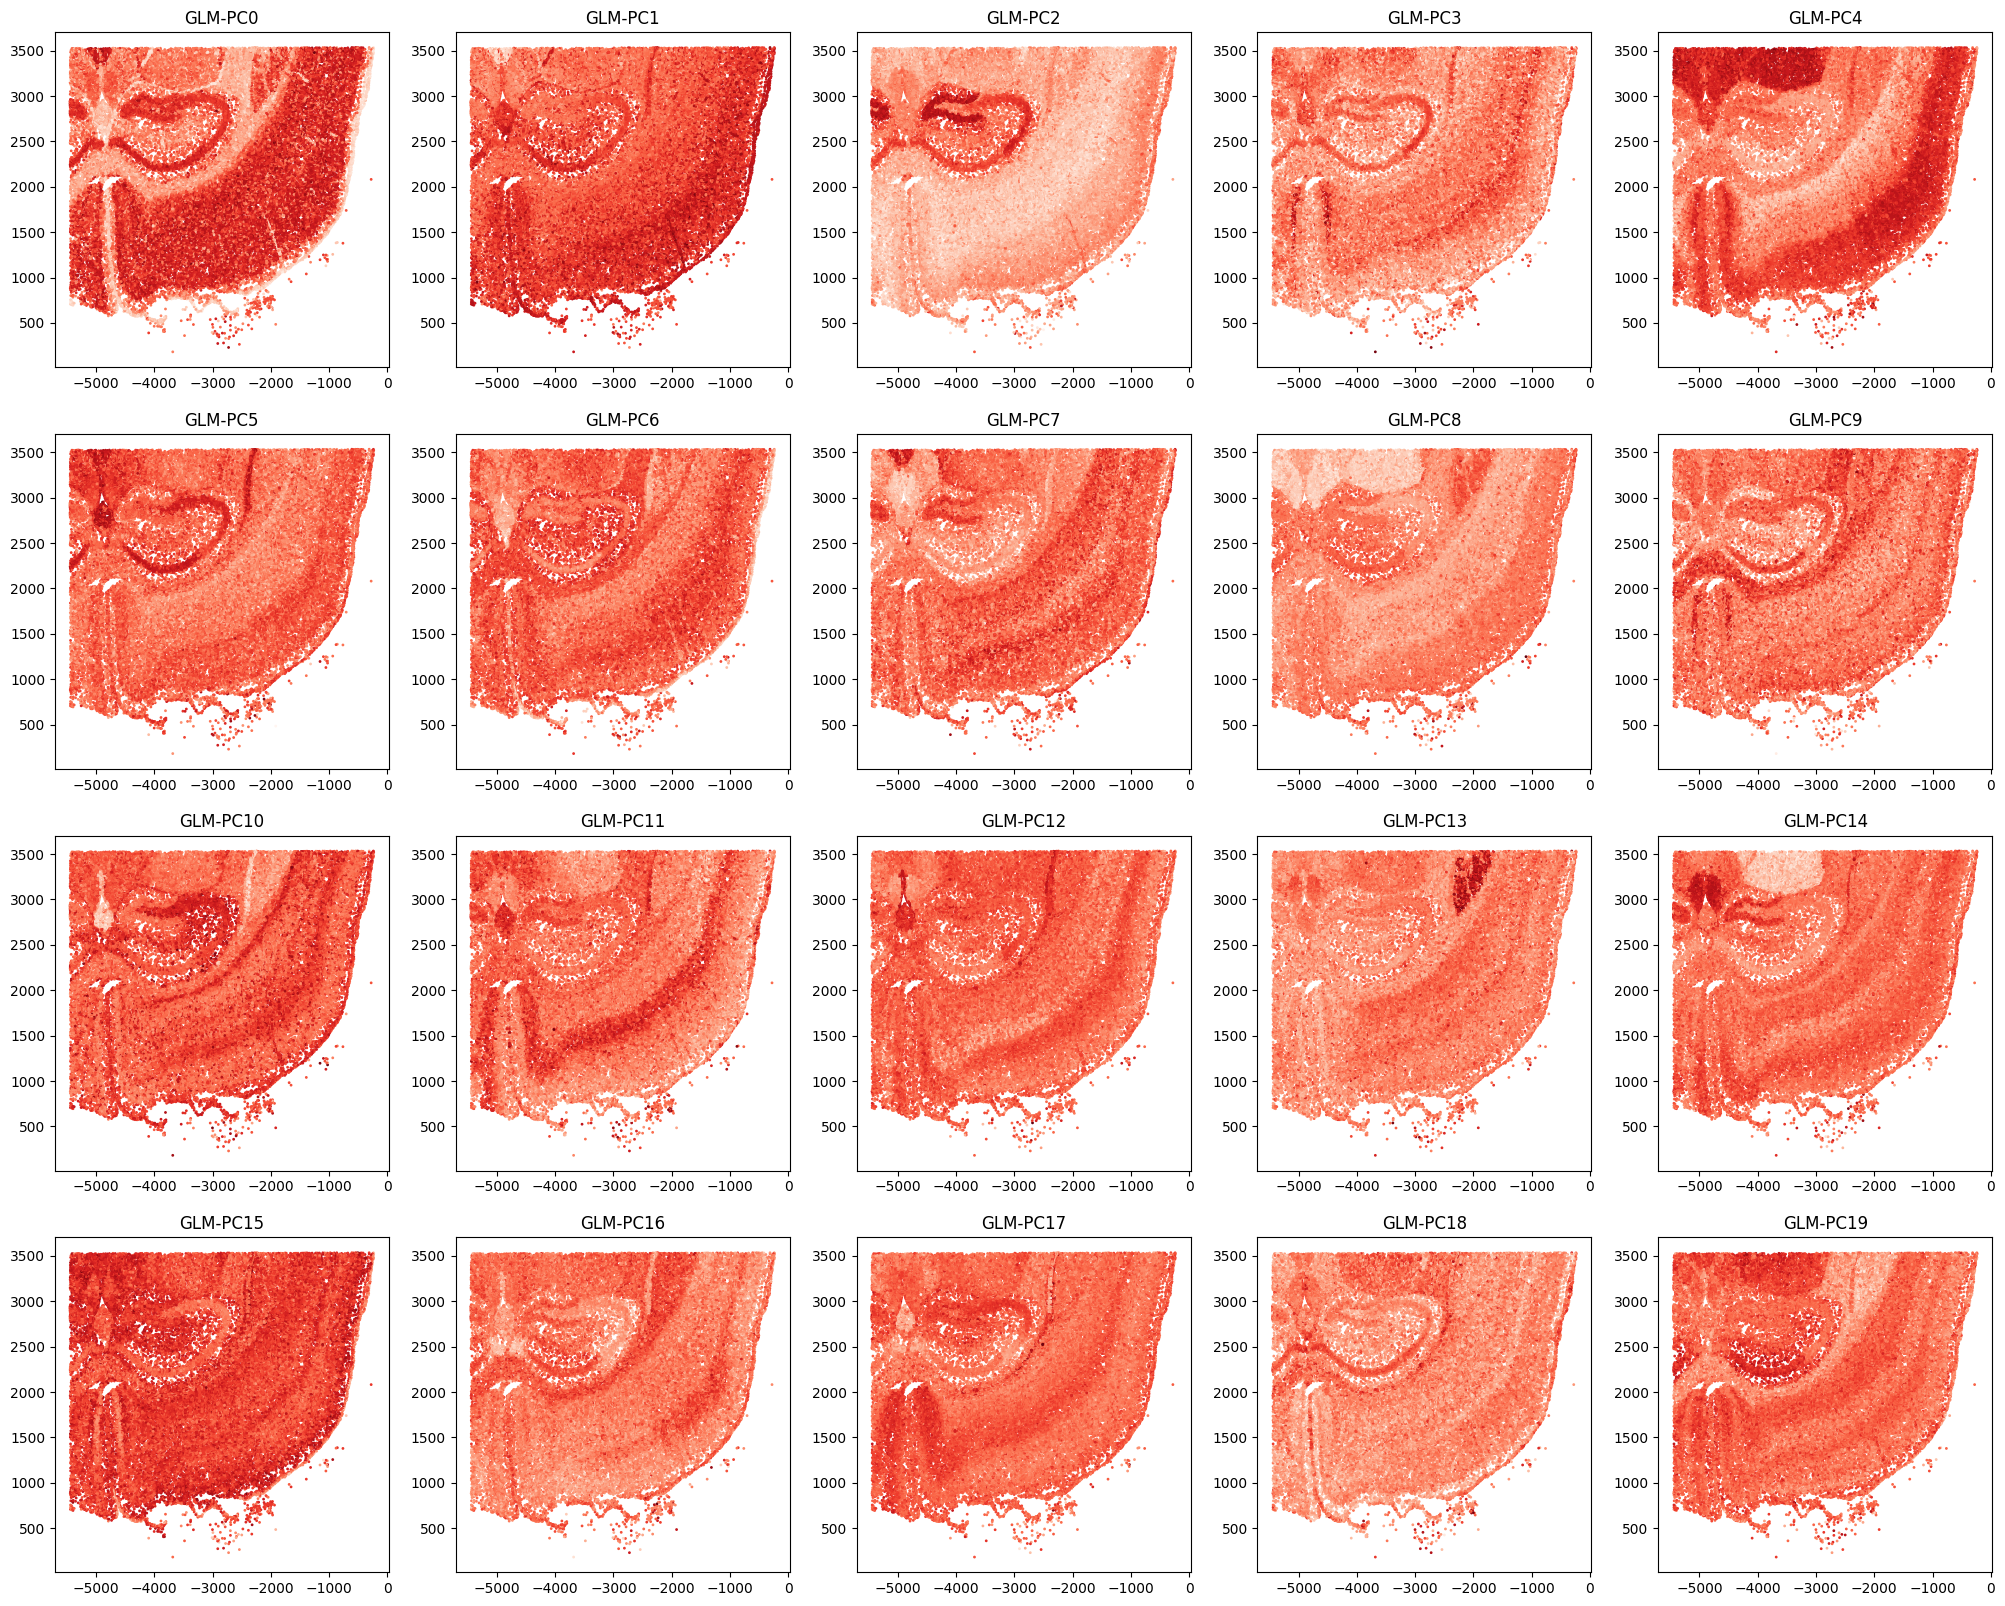

In [10]:
# visualize top GLM-PCs
R=4
C=5
fig,axs=plt.subplots(R,C,figsize=(C*5, R*5))
for r in range(R):
    for c in range(C):
        i=r*C+c
        axs[r,c].scatter(-1*coords_mat[:,0], coords_mat[:,1], c=A[:,i],cmap='Reds',s=1)
        axs[r,c].set_title(f'GLM-PC{i}')

In [11]:
np.save('results/coords_mat.npy', coords_mat)
# np.save('results/cell_labels.npy', cell_types)
np.save('results/counts_mat.npy', counts_mat)
np.save('results/gene_labels.npy', gene_labels)

In [12]:
path_to_coords='results/coords_mat.npy'
path_to_glmpca='results/glmpca.npy'

A=np.load(path_to_glmpca)
S=np.load(path_to_coords)

# z-score normalize S and A
S_torch, A_torch = neural_net.load_rescale_input_data(S,A)

In [13]:
######################################
# NEURAL NET PARAMETERS (USER CAN CHANGE)
# architectures are encoded as list, eg [20,20] means two hidden layers of size 20 hidden neurons
isodepth_arch=[100,100] # architecture for isodepth neural network d(x,y) : R^2 -> R 
expression_fn_arch=[100,100] # architecture for 1-D expression function h(w) : R -> R^G

num_epochs = 300000 # number of epochs to train NN (NOTE: it is sometimes beneficial to train longer)
checkpoint = 500 # save model after number of epochs = multiple of checkpoint
out_dir='results' # folder to save model runs
optimizer = "adam"
num_restarts=10
device='cpu' # change to 'cpu' if you don't have a GPU

######################################

seed_list=range(num_restarts)
for seed in seed_list:
    print(f'training neural network for seed {seed}')
    out_dir_seed=f"{out_dir}/rep{seed}"
    os.makedirs(out_dir_seed, exist_ok=True)
    mod, loss_list = neural_net.train(S_torch, A_torch,
                          S_hidden_list=isodepth_arch, A_hidden_list=expression_fn_arch, 
                          epochs=num_epochs, checkpoint=checkpoint, device=device,
                          save_dir=out_dir_seed, optim=optimizer, seed=seed, save_final=True)

training neural network for seed 0
Training on device: cpu
epoch: 0
epoch: 500
epoch: 1000
epoch: 1500
epoch: 2000
epoch: 2500
epoch: 3000
epoch: 3500
epoch: 4000
epoch: 4500
epoch: 5000
epoch: 5500
epoch: 6000
epoch: 6500
epoch: 7000
epoch: 7500
epoch: 8000
epoch: 8500
epoch: 9000
epoch: 9500
epoch: 10000
epoch: 10500
epoch: 11000
epoch: 11500
epoch: 12000
epoch: 12500
epoch: 13000
epoch: 13500
epoch: 14000
epoch: 14500
epoch: 15000
epoch: 15500
epoch: 16000
epoch: 16500
epoch: 17000
epoch: 17500
epoch: 18000
epoch: 18500
epoch: 19000
epoch: 19500
epoch: 20000
epoch: 20500
epoch: 21000
epoch: 21500
epoch: 22000
epoch: 22500
epoch: 23000
epoch: 23500
epoch: 24000
epoch: 24500
epoch: 25000
epoch: 25500
epoch: 26000
epoch: 26500
epoch: 27000
epoch: 27500
epoch: 28000
epoch: 28500
epoch: 29000
epoch: 29500
epoch: 30000
epoch: 30500
epoch: 31000
epoch: 31500
epoch: 32000
epoch: 32500
epoch: 33000
epoch: 33500
epoch: 34000
epoch: 34500
epoch: 35000
epoch: 35500
epoch: 36000
epoch: 36500
epo

In [14]:
import torch
import torch.nn.modules.container as nn_container

# --- Monkey-patch torch.load used inside process_NN_output ---
_old_torch_load = torch.load

def _safe_torch_load(path, *args, **kwargs):
    # Ensure allowlists and safe loading defaults
    torch.serialization.add_safe_globals([
        neural_net.GASTON,
        nn_container.Sequential,
    ])
    # Force full unpickling (trusted models only)
    kwargs["weights_only"] = False
    return _old_torch_load(path, *args, **kwargs)

process_NN_output.torch.load = _safe_torch_load
torch.load = _safe_torch_load  # optional: make global in this session

In [15]:
# --- Now call your function normally ---
gaston_model, A, S = process_NN_output.process_files("results")


best model: results/rep2


In [16]:
# gaston_model, A, S= process_NN_output.process_files('results') # model trained above

# # May need to re-load data
# # counts_mat=np.load('results/counts_mat.npy',allow_pickle=True)
# # coords_mat=np.load('results/coords_mat.npy',allow_pickle=True)
# # gene_labels=np.load('results/gene_labels.npy',allow_pickle=True)
# # cell_labels_bounded=np.load('results/cell_labels.npy',allow_pickle=True)

Kneedle number of domains: 8


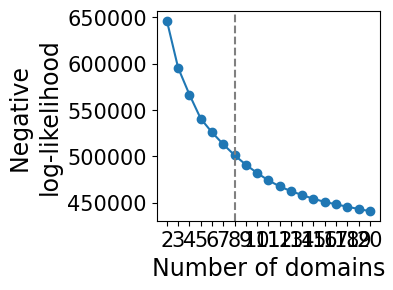

In [17]:
model_selection.plot_ll_curve(gaston_model, A, S, max_domain_num=20, start_from=2)

In [18]:
# gaston_model = torch.load("results/gaston_runs/Xenium_V1_FF_Mouse_Brain_Coronal_Subset_CTX_HP_outs/rep8/final_model.pt")
# A = torch.load("results/gaston_runs/Xenium_V1_FF_Mouse_Brain_Coronal_Subset_CTX_HP_outs/rep8/Atorch.pt")
# S = torch.load("results/gaston_runs/Xenium_V1_FF_Mouse_Brain_Coronal_Subset_CTX_HP_outs/rep8/Storch.pt")
# coords_mat = np.load("results/gaston_runs/Xenium_V1_FF_Mouse_Brain_Coronal_Subset_CTX_HP_outs/coords_mat.npy")

In [19]:
# iso = gaston_model.spatial_embedding(S).detach().cpu().numpy().flatten()
# print("Isodepth range:", iso.min(), iso.max(), " | std:", iso.std())

In [20]:
# import numpy as np
# import torch
# from gaston.dp_related import dp_bucketized, find_segments_from_dp

# def get_isodepth_labels_patched(model, A, S, num_domains, num_buckets=200, num_pcs_A=None):
#     """
#     Monkey-patched version of get_isodepth_labels() that:
#       • Normalizes isodepths
#       • Increases bucket resolution
#       • Gracefully handles missing segment_map keys (avoids KeyError)
#       • Ensures all num_domains are represented (even if empty)
#     """
#     N = A.shape[0]
#     S_torch = torch.as_tensor(S, dtype=torch.float32)

#     # Compute the isodepth embedding
#     gaston_isodepth = model.spatial_embedding(S_torch).detach().cpu().numpy().flatten()
#     gaston_isodepth = (gaston_isodepth - gaston_isodepth.min()) / np.ptp(gaston_isodepth)

#     # Optional dimensionality trimming
#     if num_pcs_A is not None:
#         A = A[:, :num_pcs_A]

#     # Build fine-grained bins
#     bin_endpoints = np.linspace(np.min(gaston_isodepth),
#                                 np.max(gaston_isodepth) + 1e-3,
#                                 num_buckets + 1)

#     # Run DP segmentation
#     error_mat, seg_map = dp_bucketized(A.T, bin_endpoints, num_domains, xcoords=gaston_isodepth)
#     bin_labels = np.digitize(gaston_isodepth, bin_endpoints)

#     # ---- patched DP traceback ----
#     segs = []
#     try:
#         segs = find_segments_from_dp(error_mat, seg_map, num_domains)
#     except KeyError as e:
#         print(f"[Warning] DP traceback incomplete: {e}. Filling missing segments.")
#         # Fallback: build empty segments for missing domains
#         existing = len(segs)
#         for _ in range(existing, num_domains):
#             segs.append([])

#     # ---- labeling ----
#     gaston_labels = np.zeros(N)
#     for c, seg in enumerate(segs):
#         for s in seg:
#             idx = np.where(bin_labels == s + 1)[0]
#             gaston_labels[idx] = c

#     return gaston_isodepth, gaston_labels
    
# from gaston import dp_related

# dp_related.get_isodepth_labels = get_isodepth_labels_patched

In [21]:
num_layers= 20 # CHANGE FOR YOUR APPLICATION (use number of layers from above)
gaston_isodepth, gaston_labels=dp_related.get_isodepth_labels(gaston_model,A,S,num_layers,500)

# DATASET-SPECIFIC: so domains are ordered outer to inner
gaston_isodepth=np.max(gaston_isodepth) - gaston_isodepth
gaston_labels=(num_layers-1)-gaston_labels

In [22]:
# bin_endpoints = np.linspace(np.min(gaston_isodepth), np.max(gaston_isodepth)+0.01, 200)
# bin_labels = np.digitize(gaston_isodepth, bin_endpoints)
# print("Number of unique bins:", len(np.unique(bin_labels)))

In [23]:
# import numpy as np
# print("Unique labels:", np.unique(gaston_labels))
# print("Label counts:", np.bincount(gaston_labels.astype(int)))

In [24]:
# import matplotlib.pyplot as plt
# plt.hist(gaston_isodepth, bins=200)
# plt.title("Distribution of Isodepth Embedding")
# plt.xlabel("Isodepth value")
# plt.ylabel("Frequency")
# plt.show()


In [25]:
# from sklearn.metrics import pairwise_distances
# import numpy as np

# def adjust_isodepth_patched(
#     gaston_isodepth, gaston_labels, coords_mat, num_domains,
#     q_vals=(0.05, 0.95), scale_factor=1.0,
#     visualize=False, figsize=(12, 12), num_rows=2,
#     s=1, return_scaling_factors=False
# ):
#     domain_ranges = []
#     q1, q2 = q_vals

#     for label in range(num_domains):
#         pts = np.where(gaston_labels == label)[0]
#         if len(pts) == 0:
#             print(f"[Warning] Domain {label} has no points — skipping.")
#             domain_ranges.append(np.nan)
#             continue

#         vals = gaston_isodepth[pts]
#         pts1 = [t for t in pts if vals[np.where(pts == t)] < np.quantile(vals, q1)]
#         pts2 = [t for t in pts if vals[np.where(pts == t)] > np.quantile(vals, q2)]

#         if len(pts1) == 0 or len(pts2) == 0:
#             print(f"[Warning] Domain {label}: insufficient points for quantile separation — skipping.")
#             domain_ranges.append(np.nan)
#             continue

#         zzz = pairwise_distances(coords_mat[pts1, :], coords_mat[pts2, :])
#         domain_ranges.append(np.median(np.min(zzz, 1)) * scale_factor)

#     if return_scaling_factors:
#         return gaston_isodepth, np.array(domain_ranges)
#     else:
#         return gaston_isodepth

# import gaston.isodepth_scaling as isodepth_scaling
# isodepth_scaling.adjust_isodepth = adjust_isodepth_patched

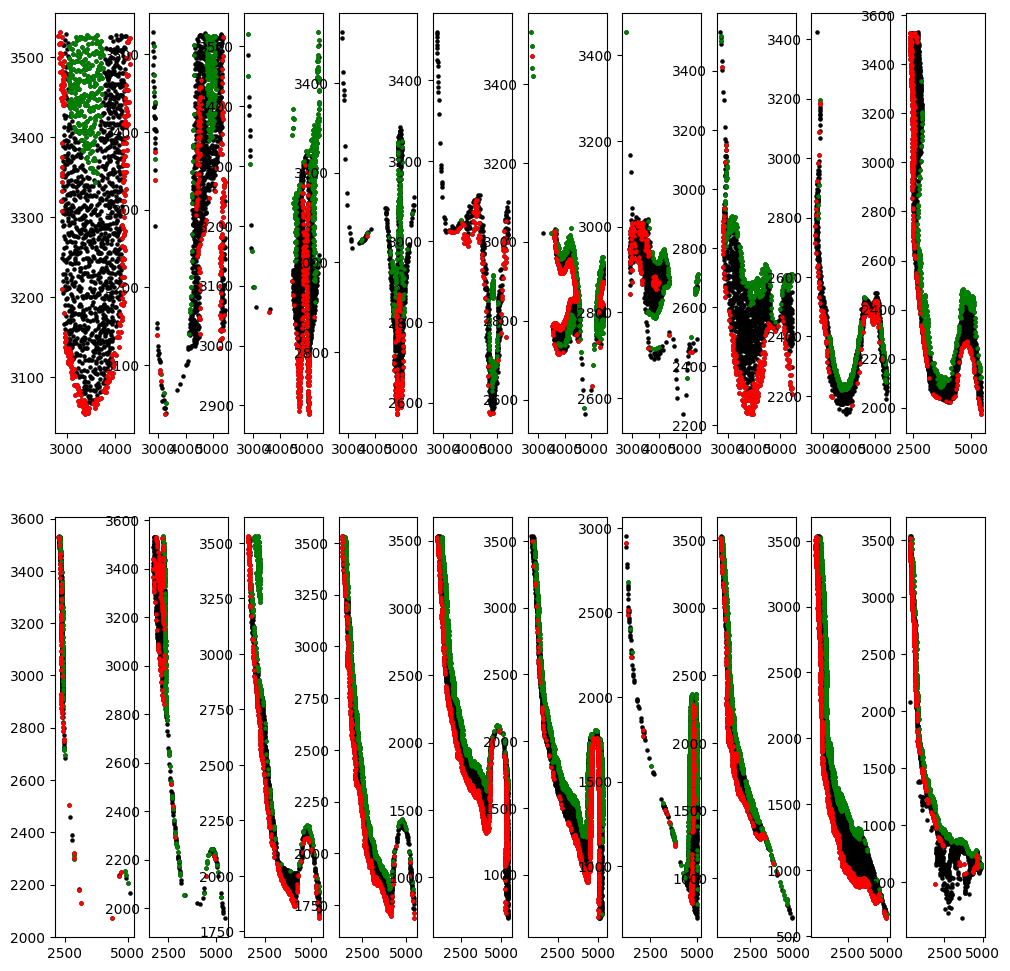

In [26]:
# WITH VISUALIZATION
gaston_isodepth,scaling_factors=isodepth_scaling.adjust_isodepth(gaston_isodepth, gaston_labels, coords_mat, num_domains=num_layers,
                                  visualize=True, figsize=(12,12),num_rows=2,
                                                return_scaling_factors=True)

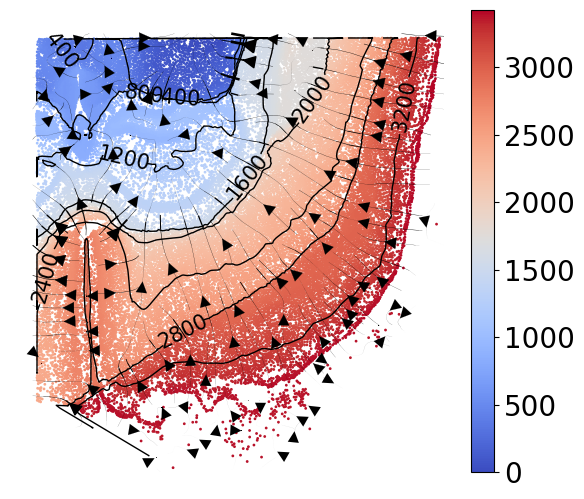

In [27]:
show_streamlines=True

linear_transform=np.array([[-1,0],[0,1]]) # reflect points across x axis
cluster_plotting.plot_isodepth(gaston_isodepth, S, gaston_model, 
                               figsize=(7,6), streamlines=show_streamlines, s=1,
                              scaling_factors=scaling_factors,
                              gaston_labels_for_scaling=gaston_labels,
                              streamlines_lw=2, contour_levels=10, 
                               cbar_fs=20, contour_fs=15,
                               linear_transform=linear_transform)

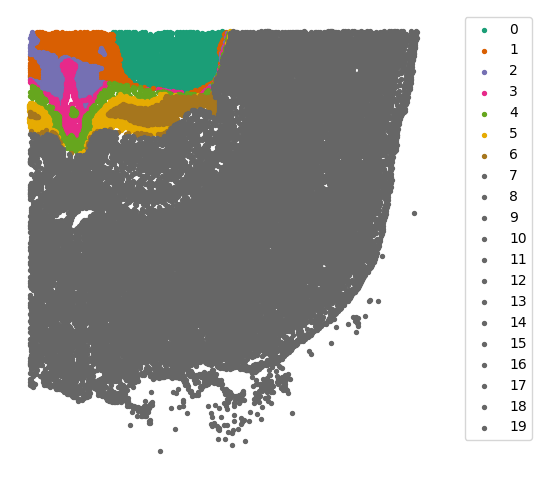

In [28]:
# layer_colors=['darksalmon', 'deepskyblue', 'limegreen', 'red', 'blue']
# labels=['Invasive tumor domain', 'Stromal domain', 'Immune domain', 'DCIS domain']

cluster_plotting.plot_clusters(gaston_labels, S, figsize=(5.5,6), 
                               s=8, lgd=True, 
                              bbox_to_anchor=(1.05,1),linear_transform=linear_transform)

In [30]:
adata.obs

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,control_codeword_counts,total_counts,cell_area,nucleus_area
1,1,1898.814917,2540.963147,384,0,0,385,305.211094,70.714687
2,2,1895.304724,2532.626880,146,0,0,146,176.606094,6.412187
3,3,2368.073230,2534.409265,81,0,0,81,263.938281,32.783437
4,4,1903.726282,2560.009912,314,0,0,315,427.810313,68.185938
5,5,1917.481299,2543.131934,639,0,0,640,424.604219,102.956250
...,...,...,...,...,...,...,...,...,...
36598,36598,3341.792432,3347.323865,352,0,0,352,466.960781,67.373125
36599,36599,3370.737878,3357.877063,412,1,0,413,576.193750,6.863750
36600,36600,3333.378137,3360.594324,161,0,0,161,398.323281,13.230781
36601,36601,3322.742554,3312.781409,387,0,0,387,510.762344,21.313750


In [31]:
adata.obs['gaston_labels'] = gaston_labels

In [32]:
adata.write("results/gaston_domains.h5ad")